In [129]:
import pandas as pd
import matplotlib.pyplot as plt
imp_1 = pd.read_csv(f'derived/imp_2.csv', sep=',')
exp_1 = pd.read_csv(f'derived/exp_2.csv', sep=',')

In [130]:
print(imp_1.columns)
print(exp_1.columns)

Index(['Country', 'Info', 'Month', 'Year', 'Value', 'Code'], dtype='str')
Index(['Country', 'Info', 'Month', 'Year', 'Value', 'Code'], dtype='str')


## Market share do Brasil na indústria

## Índice intra-indústria

In [131]:
import pandas as pd
import numpy as np

colunas_chave = exp_1.columns.difference(['Value', 'Country', 'Month', 'Code']).tolist()

df_exp = exp_1.groupby(colunas_chave)['Value'].sum().reset_index()
df_exp = df_exp.rename(columns={'Value': 'X_k'})

df_imp = imp_1.groupby(colunas_chave)['Value'].sum().reset_index()
df_imp = df_imp.rename(columns={'Value': 'M_k'})

df_final = pd.merge(df_exp, df_imp, on=colunas_chave, how='outer')

df_final['X_k'] = df_final['X_k'].fillna(0)
df_final['M_k'] = df_final['M_k'].fillna(0)

df_final['Trade_Total'] = df_final['X_k'] + df_final['M_k']

df_final['Bk'] = np.where(
    df_final['Trade_Total'] > 0,
    (df_final['X_k'] - df_final['M_k']) / df_final['Trade_Total'],
    np.nan
)

df_final = df_final.sort_values(by=['Year']).reset_index(drop=True)

print(df_final.head())
print(df_final['X_k'].unique())

                                                Info  Year         X_k  \
0  Selos postais, fiscais e semelhantes, não obli...  2016      7057.0   
1  Cartões-postais impressos ou ilustrados; cartõ...  2016      1679.0   
2  Papel-pergaminho e cartão-pergaminho (sulfuriz...  2016   3160689.0   
3    Blocos e chapas, filtrantes, de pasta de papel.  2016      4028.0   
4  Caixas, sacos, bolsas, cartuchos e outras emba...  2016  93365436.0   

        M_k  Trade_Total        Bk  
0     33643      40700.0 -0.653219  
1    157021     158700.0 -0.978841  
2   9408894   12569583.0 -0.497089  
3     47026      51054.0 -0.842206  
4  25359011  118724447.0  0.572809  
[7.05700000e+03 1.67900000e+03 3.16068900e+06 4.02800000e+03
 9.33654360e+07 7.79270000e+04 5.20552000e+05 1.16845000e+05
 1.29007907e+10 7.85883000e+05 5.79790000e+05 5.16000000e+02
 2.35341200e+06 6.65700000e+03 1.41228620e+07 1.21670320e+07
 4.43183220e+07 1.26106110e+07 9.39054000e+05 4.65388300e+06
 4.06089530e+08 2.70000000e+

In [132]:
infos = df_final['Info'].unique()
# infos

In [133]:
info_1 = {
    "Pastas de madeira ou de outras matérias fibrosas celulósicas; papel ou cartão para reciclar (desperdícios e resíduos).": '47',
    "Papel e cartão; obras de pasta de celulose, papel ou de cartão.": '48',
    "Livros, jornais, gravuras e outros produtos das indústrias gráficas; textos manuscritos ou datilografados, planos e plantas.": '49'
}

info_2 = {
    # Capítulo 47
    '4701': "Pastas mecânicas de madeira",
    '4702': "Pastas químicas de madeira, para dissolução",
    '4703': "Pastas químicas de madeira, à soda ou ao sulfato, exceto pastas para dissolução.",
    '4704': "Pastas químicas de madeira, ao bissulfito, exceto pastas para dissolução.",
    '4705': "Pastas de madeira obtidas por combinação de um tratamento mecânico com um tratamento químico.",
    '4706': "Pastas de fibras obtidas a partir de papel ou cartão reciclados (desperdícios e resíduos) ou de outras matérias fibrosas celulósicas.",
    '4707': "Papel ou cartão para reciclar (desperdícios e resíduos).",
    
    # Capítulo 48
    '4801': "Papel de jornal, em rolos ou em folhas.",
    '4802': "Papel e cartão, não revestidos, do tipo utilizado para escrita, impressão ou outros fins gráficos, e papel e cartão para fabricar cartões ou tiras perfurados, não perfurados, em rolos ou em folhas de forma quadrada ou retangular, de qualquer dimensão, com exclusão do papel das posições 48.01 ou 48.03; papel e cartão feitos à mão (folha a folha).",
    '4803': "Papel do tipo utilizado para papel higiênico, lenços (toalhitas) demaquilantes, toalhas, guardanapos ou para papel semelhante de uso doméstico, higiênico ou toucador, pasta (ouate) de celulose e mantas de fibras de celulose, mesmo encrespados, plissados, gofrados, estampados, perfurados, coloridos à superfície, decorados à superfície ou impressos, em rolos ou em folhas.",
    '4804': "Papel e cartão, Kraft, não revestidos, em rolos ou em folhas, exceto os das posições 48.02 e 48.03.",
    '4805': "Outro papel e cartão, não revestidos, em rolos ou em folhas, não tendo sofrido trabalho complementar nem tratamentos, exceto os especificados na Nota 3 do presente Capítulo.",
    '4806': "Papel-pergaminho e cartão-pergaminho (sulfurizados), papel impermeável a gorduras, papel vegetal, papel cristal e outro papel calandrado transparente ou translúcido, em rolos ou em folhas.",
    '4807': "Papel e cartão obtidos por colagem de folhas sobrepostas, não revestidos na superfície nem impregnados, mesmo reforçados interiormente, em rolos ou em folhas.",
    '4808': "Papel e cartão ondulados (canelados*) (mesmo recobertos por colagem), encrespados, plissados, gofrados, estampados ou perfurados, em rolos ou em folhas, exceto o papel do tipo descrito no texto da posição 48.03.",
    '4809': "Papel-carbono (papel químico), papel autocopiativo e outro papel para cópia ou duplicação (incluindo o revestido ou impregnado, para estênceis ou para chapas ofsete), mesmo impresso, em rolos ou em folhas.",
    '4810': "Papel e cartão revestidos de caulim (caulino) ou de outras substâncias inorgânicas numa ou nas duas faces, mesmo com aglutinantes, sem qualquer outro revestimento, mesmo coloridos à superfície, decorados à superfície ou impressos, em rolos ou em folhas de forma quadrada ou retangular, de qualquer dimensão.",
    '4811': "Papel, cartão, pasta (ouate) de celulose e mantas de fibras de celulose, revestidos, impregnados, recobertos, coloridos à superfície, decorados à superfície ou impressos, em rolos ou em folhas de forma quadrada ou retangular, de qualquer dimensão, exceto os produtos do tipo descrito nos textos das posições 48.03, 48.09 ou 48.10.",
    '4812': "Blocos e chapas, filtrantes, de pasta de papel.",
    '4813': "Papel para cigarros, mesmo cortado nas dimensões próprias, em cadernos ou em tubos.",
    '4814': "Papel de parede e revestimentos para parede semelhantes; papel para vitrais.",
    '4816': "Papel-carbono (papel químico), papel autocopiativo e outro papel para cópia ou duplicação (exceto os da posição 48.09), estênceis completos e chapas ofsete, de papel, mesmo acondicionados em caixas.",
    '4817': "Envelopes, aerogramas, cartões-postais não ilustrados e cartões para correspondência, de papel ou cartão; caixas, sacos e semelhantes, de papel ou cartão, que contenham um sortido de artigos para correspondência.",
    '4818': "Papel do tipo utilizado para papel higiênico e papel semelhante, pasta (ouate) de celulose ou mantas de fibras de celulose, do tipo utilizado para fins domésticos ou sanitários, em rolos de largura não superior a 36 cm, ou cortados em forma própria; lenços, lenços (toalhitas) demaquilantes, toalhas de mão, toalhas de mesa, guardanapos, lençóis e artigos semelhantes, de uso doméstico, de toucador, higiênicos ou hospitalares, vestuário e seus acessórios, de pasta de papel, papel, pasta (ouate) de celulose ou de mantas de fibras de celulose.",
    '4819': "Caixas, sacos, bolsas, cartuchos e outras embalagens, de papel, cartão, pasta (ouate) de celulose ou de mantas de fibras de celulose; cartonagens para escritórios, lojas e estabelecimentos semelhantes.",
    '4820': "Livros de registro e de contabilidade, blocos de notas, de encomendas, de recibos, de apontamentos, de papel para cartas, agendas e artigos semelhantes, cadernos, classificadores, encadernações (de folhas soltas ou outras), capas de processos e outros artigos escolares, de escritório ou de papelaria, incluindo os formulários em blocos de papel múltiplas vias, mesmo com folhas intercaladas de papel-carbono (papel químico), de papel ou cartão; álbuns para amostras ou para coleções e capas para livros, de papel ou cartão.",
    '4821': "Etiquetas de qualquer espécie, de papel ou cartão, impressas ou não.",
    '4822': "Carretéis, bobinas, canelas e suportes semelhantes, de pasta de papel, papel ou cartão, mesmo perfurados ou endurecidos.",
    '4823': "Outro papel, cartão, pasta (ouate) de celulose e mantas de fibras de celulose, cortados em forma própria; outras obras de pasta de papel, papel, cartão, pasta (ouate) de celulose ou de mantas de fibras de celulose.",

    # Capítulo 49
    '4901': "Livros, brochuras e impressos semelhantes, mesmo em folhas soltas.",
    '4902': "Jornais e publicações periódicas, impressos, mesmo ilustrados ou que contenham publicidade.",
    '4903': "Álbuns ou livros de ilustrações e álbuns para desenhar ou colorir, para crianças.",
    '4904': "Música manuscrita ou impressa, ilustrada ou não, mesmo encadernada.",
    '4905': "Obras cartográficas de qualquer espécie, incluindo as cartas murais, as plantas topográficas e os globos, impressas.",
    '4906': "Planos, plantas e desenhos, de arquitetura, de engenharia e outros planos e desenhos industriais, comerciais, topográficos ou semelhantes, originais, feitos à mão; textos manuscritos; reproduções fotográficas em papel sensibilizado e cópias a papel-carbono (papel químico) dos planos, plantas, desenhos ou textos acima referidos.",
    '4907': "Selos postais, fiscais e semelhantes, não obliterados, tendo ou destinando-se a ter curso legal no país em que têm, ou terão, um valor facial reconhecido; papel selado; notas (papéis-moeda); cheques; certificados de ações ou de obrigações e títulos semelhantes.",
    '4908': "Decalcomanias de qualquer espécie.",
    '4909': "Cartões-postais impressos ou ilustrados; cartões impressos com votos ou mensagens pessoais, mesmo ilustrados, mesmo com envelopes, guarnições ou aplicações.",
    '4910': "Calendários de qualquer espécie, impressos, incluindo os blocos-calendários para desfolhar.",
    '4911': "Outros impressos, incluindo as estampas, gravuras e fotografias."
}

info_2 = {v: k for k, v in info_2.items()}

In [134]:
# import matplotlib.pyplot as plt

# # Cria a figura com os dois subplots
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# # Listas para guardar as informações da pizza
# pie_sizes = []
# pie_labels = []
# pie_colors = []

# for info in infos:
#     filtered = df_final[df_final['Info'] == info].copy()
#     filtered = filtered.sort_values(by=['Year'])

#     # Plota a linha em ax1 e salva a cor gerada
#     linha = ax1.plot(filtered['Year'], filtered['Bk'], markeredgewidth=2, label=info_1[info])
#     cor = linha[0].get_color()

#     # Agrupa o Total de Trade para a pizza (soma de todos os anos)
#     total_trade = filtered['Trade_Total'].sum()
    
#     # Alimenta as listas da pizza
#     pie_sizes.append(total_trade)
#     pie_labels.append(info_1[info])
#     pie_colors.append(cor)

# # --- Configurações do ax1 (Linha) ---
# ax1.axhline(0, color='gray', linestyle='--', linewidth=1)
# ax1.set_title("Indicador de Balassa", fontsize=20, pad=20)
# ax1.set(ylim=(-1.1, 1.1))

# # Atenção aqui: Mudei a posição da legenda. 
# # Se usar (1.05, 1) em ax1, a legenda vai ficar por cima do gráfico de pizza.
# # Coloquei abaixo do gráfico de linha para ficar mais limpo.

# # --- Configurações do ax2 (Pizza) ---
# if sum(pie_sizes) > 0:
#     ax2.pie(pie_sizes, labels=pie_labels, colors=pie_colors, autopct='%1.1f%%', pctdistance=1.2, 
#             startangle=90, wedgeprops={'edgecolor': 'white'}, labeldistance=None)
#     ax2.set_title("Total de movimentações", fontsize=20, pad=20)
# ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# # Ajusta os espaçamentos para nada ficar sobreposto
# plt.tight_layout()
# plt.show()

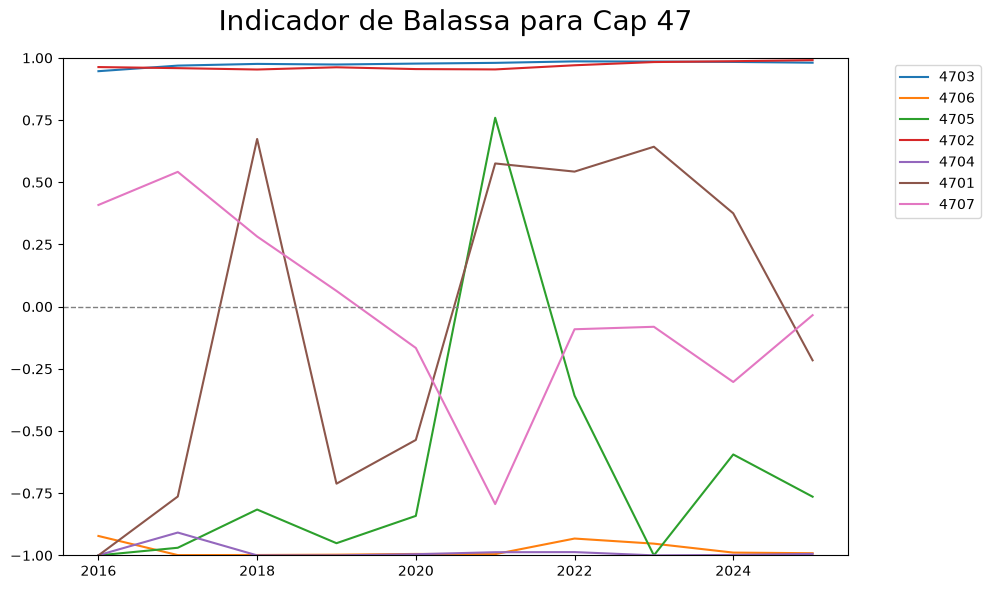

In [135]:
import matplotlib.pyplot as plt

# Dicionários globais para guardar as informações para a Célula 2
dados_pizza = {}
cores_mapeadas = {}

fig, ax1 = plt.subplots(figsize=(10, 6))

for info in infos:
    num = info_2[info]
    if num[:2] == '47':
        filtered = df_final[df_final['Info'] == info].copy()
        filtered = filtered.sort_values(by=['Year'])

        # 1. Plota a linha e captura a cor gerada automaticamente
        linha = ax1.plot(filtered['Year'], filtered['Bk'], markeredgewidth=2, label=num)
        cor_da_linha = linha[0].get_color()

        # 2. Salva a cor e o total na memória para a próxima célula
        cores_mapeadas[num] = cor_da_linha
        dados_pizza[num] = filtered['Trade_Total'].sum()

# Configurações visuais
ax1.axhline(0, color='gray', linestyle='--', linewidth=1)
ax1.set_title("Indicador de Balassa para Cap 47", fontsize=20, pad=20)
ax1.set(ylim=(-1, 1))

# Coloca a legenda para fora do gráfico
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

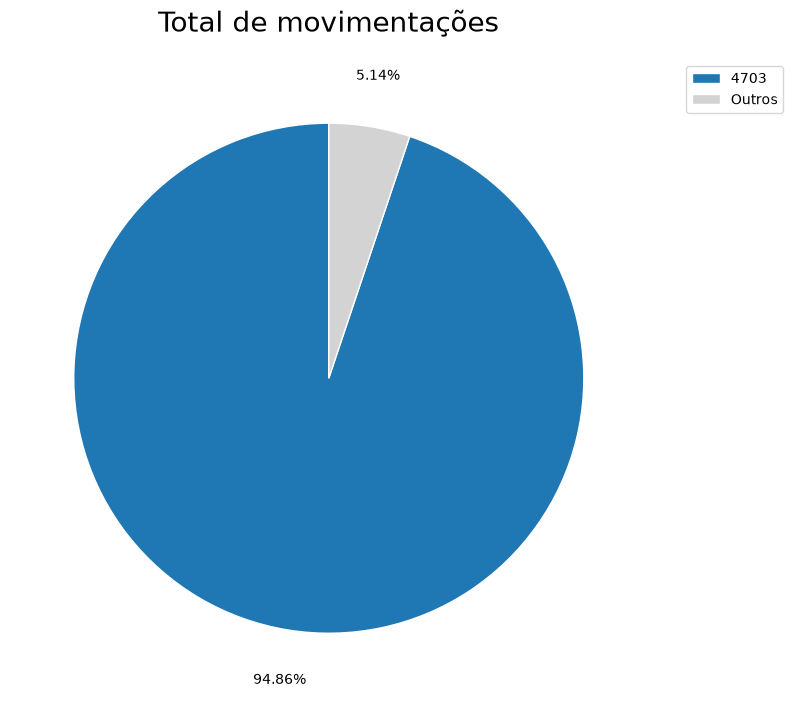

In [136]:
import matplotlib.pyplot as plt

# Calcula o total geral com base nos dados salvos na Célula 1
total_geral = sum(dados_pizza.values())

pie_sizes_principais = []
pie_labels_principais = []
pie_colors_principais = []
soma_outros = 0

# Filtra quem tem >= 1% do total
for num, total in dados_pizza.items():
    if total_geral > 0 and (total / total_geral) * 100 >= 5.0:
        pie_sizes_principais.append(total)
        pie_labels_principais.append(num)
        # Puxa a cor exata que foi usada na linha daquela categoria
        pie_colors_principais.append(cores_mapeadas[num]) 
    else:
        soma_outros += total

# Adiciona a fatia "Outros" se houver itens pequenos
if soma_outros > 0:
    pie_sizes_principais.append(soma_outros)
    pie_labels_principais.append("Outros")
    pie_colors_principais.append('lightgray') # Cor neutra

# Cria a figura exclusiva para a pizza
fig, ax2 = plt.subplots(figsize=(8, 8))

if sum(pie_sizes_principais) > 0:
    ax2.pie(pie_sizes_principais, labels=pie_labels_principais, colors=pie_colors_principais, 
            autopct='%1.2f%%', startangle=90, wedgeprops={'edgecolor': 'white'}, labeldistance=None, pctdistance=1.2)
    ax2.set_title("Total de movimentações", fontsize=20, pad=20)

# Legenda da pizza ajustada
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

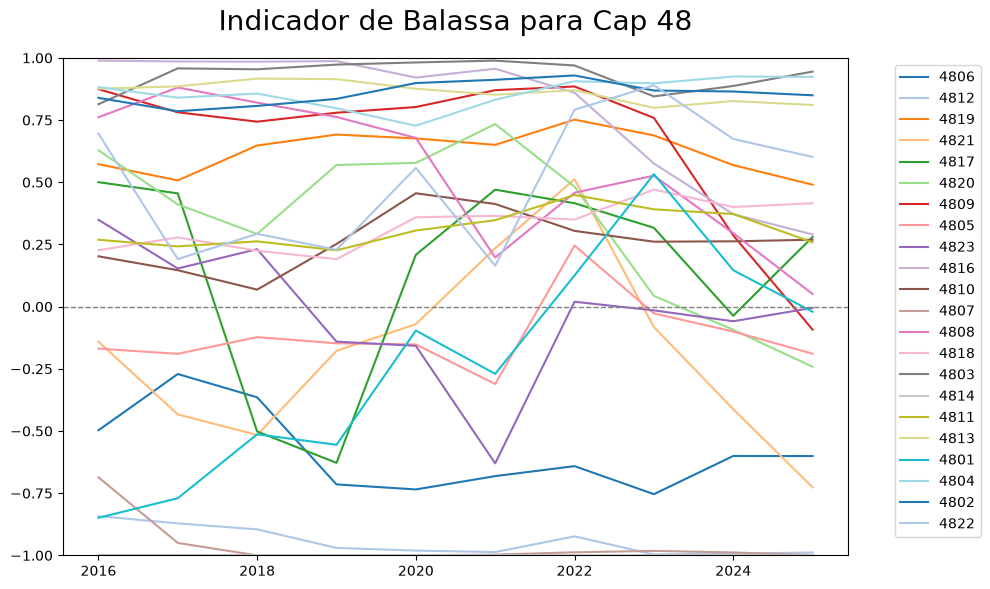

In [137]:
import matplotlib.pyplot as plt

# Dicionários globais para guardar as informações para a Célula 2
dados_pizza = {}
cores_mapeadas = {}

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_prop_cycle(color=plt.cm.tab20.colors)

for info in infos:
    num = info_2[info]
    if num[:2] == '48':
        filtered = df_final[df_final['Info'] == info].copy()
        filtered = filtered.sort_values(by=['Year'])

        # 1. Plota a linha e captura a cor gerada automaticamente
        linha = ax1.plot(filtered['Year'], filtered['Bk'], markeredgewidth=2, label=num)
        cor_da_linha = linha[0].get_color()

        # 2. Salva a cor e o total na memória para a próxima célula
        cores_mapeadas[num] = cor_da_linha
        dados_pizza[num] = filtered['Trade_Total'].sum()

# Configurações visuais
ax1.axhline(0, color='gray', linestyle='--', linewidth=1)
ax1.set_title("Indicador de Balassa para Cap 48", fontsize=20, pad=20)
ax1.set(ylim=(-1, 1))

# Coloca a legenda para fora do gráfico
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

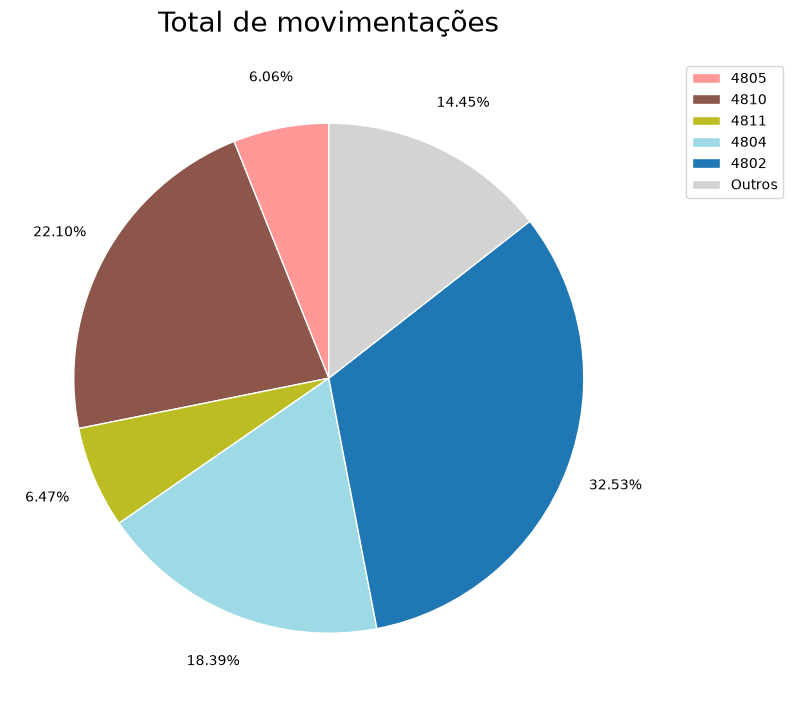

In [138]:
import matplotlib.pyplot as plt

# Calcula o total geral com base nos dados salvos na Célula 1
total_geral = sum(dados_pizza.values())

pie_sizes_principais = []
pie_labels_principais = []
pie_colors_principais = []
soma_outros = 0

# Filtra quem tem >= 1% do total
for num, total in dados_pizza.items():
    if total_geral > 0 and (total / total_geral) * 100 >= 5.0:
        pie_sizes_principais.append(total)
        pie_labels_principais.append(num)
        # Puxa a cor exata que foi usada na linha daquela categoria
        pie_colors_principais.append(cores_mapeadas[num]) 
    else:
        soma_outros += total

# Adiciona a fatia "Outros" se houver itens pequenos
if soma_outros > 0:
    pie_sizes_principais.append(soma_outros)
    pie_labels_principais.append("Outros")
    pie_colors_principais.append('lightgray') # Cor neutra

# Cria a figura exclusiva para a pizza
fig, ax2 = plt.subplots(figsize=(8, 8))

if sum(pie_sizes_principais) > 0:
    ax2.pie(pie_sizes_principais, labels=pie_labels_principais, colors=pie_colors_principais, 
            autopct='%1.2f%%', startangle=90, wedgeprops={'edgecolor': 'white'}, labeldistance=None, pctdistance=1.2)
    ax2.set_title("Total de movimentações", fontsize=20, pad=20)

# Legenda da pizza ajustada
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

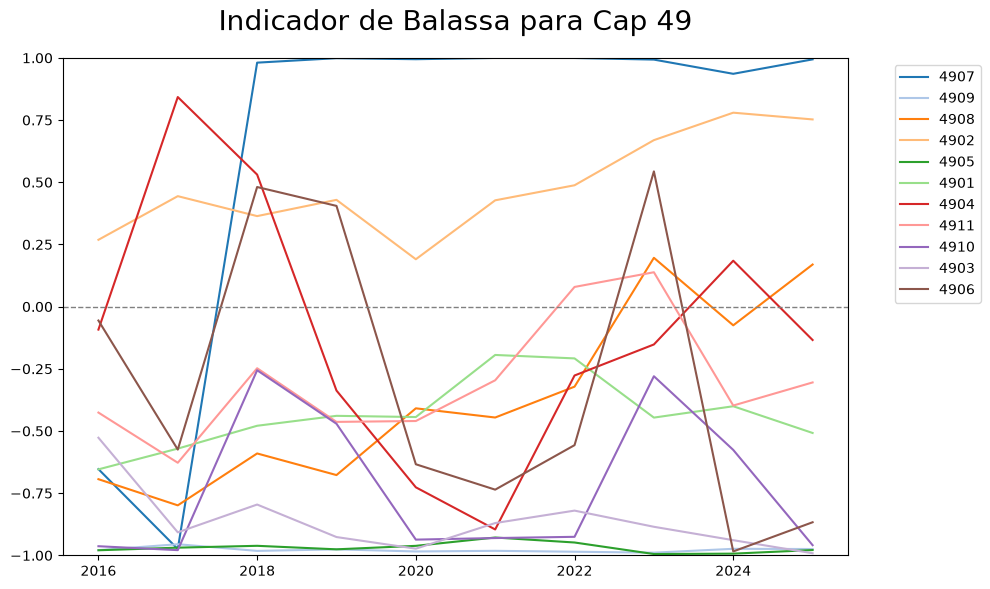

In [148]:
import matplotlib.pyplot as plt

# Dicionários globais para guardar as informações para a Célula 2
dados_pizza = {}
cores_mapeadas = {}

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_prop_cycle(color=plt.cm.tab20.colors)

for info in infos:
    num = info_2[info]
    if num[:2] == '49':
        filtered = df_final[df_final['Info'] == info].copy()
        filtered = filtered.sort_values(by=['Year'])

        # 1. Plota a linha e captura a cor gerada automaticamente
        linha = ax1.plot(filtered['Year'], filtered['Bk'], markeredgewidth=2, label=num)
        cor_da_linha = linha[0].get_color()

        # 2. Salva a cor e o total na memória para a próxima célula
        cores_mapeadas[num] = cor_da_linha
        dados_pizza[num] = filtered['Trade_Total'].sum()

# Configurações visuais
ax1.axhline(0, color='gray', linestyle='--', linewidth=1)
ax1.set_title("Indicador de Balassa para Cap 49", fontsize=20, pad=20)
ax1.set(ylim=(-1, 1))

# Coloca a legenda para fora do gráfico
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

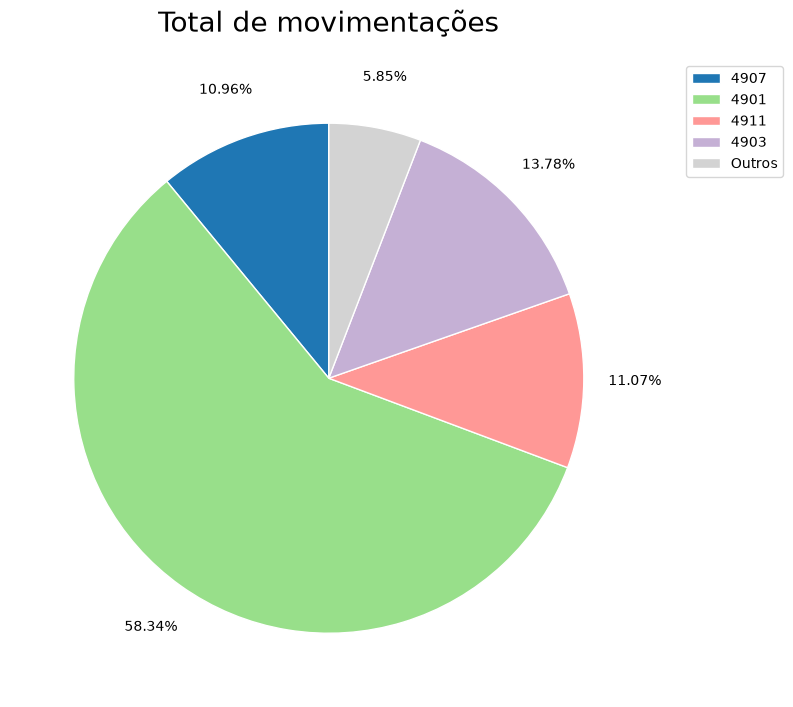

In [149]:
import matplotlib.pyplot as plt

# Calcula o total geral com base nos dados salvos na Célula 1
total_geral = sum(dados_pizza.values())

pie_sizes_principais = []
pie_labels_principais = []
pie_colors_principais = []
soma_outros = 0

# Filtra quem tem >= 1% do total
for num, total in dados_pizza.items():
    if total_geral > 0 and (total / total_geral) * 100 >= 5.0:
        pie_sizes_principais.append(total)
        pie_labels_principais.append(num)
        # Puxa a cor exata que foi usada na linha daquela categoria
        pie_colors_principais.append(cores_mapeadas[num]) 
    else:
        soma_outros += total

# Adiciona a fatia "Outros" se houver itens pequenos
if soma_outros > 0:
    pie_sizes_principais.append(soma_outros)
    pie_labels_principais.append("Outros")
    pie_colors_principais.append('lightgray') # Cor neutra

# Cria a figura exclusiva para a pizza
fig, ax2 = plt.subplots(figsize=(8, 8))

if sum(pie_sizes_principais) > 0:
    ax2.pie(pie_sizes_principais, labels=pie_labels_principais, colors=pie_colors_principais, 
            autopct='%1.2f%%', startangle=90, wedgeprops={'edgecolor': 'white'}, labeldistance=None, pctdistance=1.2)
    ax2.set_title("Total de movimentações", fontsize=20, pad=20)

# Legenda da pizza ajustada
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

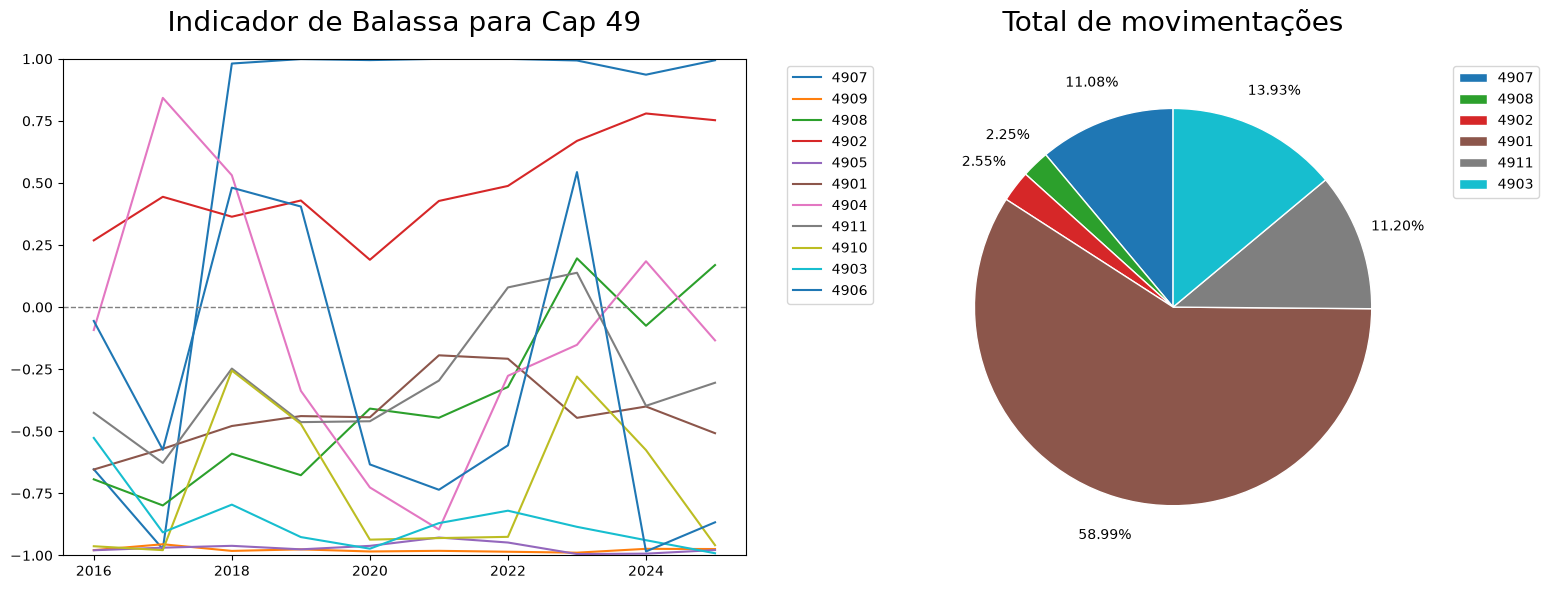

In [141]:
import matplotlib.pyplot as plt

# 1. Cria a figura com 1 linha e 2 colunas de subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Listas para armazenar os dados do gráfico de pizza
pie_sizes = []
pie_labels = []
pie_colors = []

for info in infos:
    num = info_2[info]
    if num[:2] == '49':
        filtered = df_final[df_final['Info'] == info].copy()
        filtered = filtered.sort_values(by=['Year'])

        # 2. Plota o gráfico de linha no ax1 e captura a cor gerada
        linha = ax1.plot(filtered['Year'], filtered['Bk'], markeredgewidth=2, label=info_2[info])
        cor_da_linha = linha[0].get_color()

        # 3. Coleta os dados para a pizza
        total_trade = filtered['Trade_Total'].sum()
        
        pie_sizes.append(total_trade)
        pie_labels.append(info_2[info])
        pie_colors.append(cor_da_linha) # Sincroniza a cor da pizza com a da linha

# --- Configurações do subplot 1 (Linha) ---
ax1.axhline(0, color='gray', linestyle='--', linewidth=1)
ax1.set_title("Indicador de Balassa para Cap 49", fontsize=20, pad=20)
ax1.set(ylim=(-1, 1))
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# --- Filtro para desconsiderar os menores na Pizza ---
limite_percentual = 0.02 # Ignora categorias que representam menos de 2% do total. Ajuste se necessário.
soma_total = sum(pie_sizes)

tamanhos_finais = []
labels_finais = []
cores_finais = []

# Varre as listas originais e só guarda o que for maior ou igual ao limite
for tamanho, label, cor in zip(pie_sizes, pie_labels, pie_colors):
    if (tamanho / soma_total) >= limite_percentual:
        tamanhos_finais.append(tamanho)
        labels_finais.append(label)
        cores_finais.append(cor)

# --- Configurações do subplot 2 (Pizza) ---
if sum(tamanhos_finais) > 0: 
    # Plota usando as listas filtradas (tamanhos_finais, labels_finais, cores_finais)
    ax2.pie(tamanhos_finais, labels=labels_finais, colors=cores_finais, autopct='%1.2f%%', 
            startangle=90, wedgeprops={'edgecolor': 'white'}, pctdistance=1.2, labeldistance=None)
    ax2.set_title("Total de movimentações", fontsize=20, pad=20)

# Legenda baseada nos itens que sobraram no gráfico de pizza
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Ajusta o layout para evitar sobreposições de textos
plt.tight_layout()
plt.show()

## Peso da indústria no Brasil (concentração)

In [142]:
frames = []
for year in range(2016, 2026):
    try:
        df_year = pd.read_csv(f'Dados/EXP_{year}.csv', sep=';')
        frames.append(df_year)
    except FileNotFoundError:
        print(f'File Dados/EXP_{year}.csv not found, skipping.')

exp_total = pd.concat(frames, ignore_index=True) if frames else pd.exp_totalFrame()

print(exp_total.head())

   CO_ANO  CO_MES    CO_NCM  CO_UNID  CO_PAIS SG_UF_NCM  CO_VIA   CO_URF  \
0    2016      11  82119320       11      158        RS       7  1010900   
1    2016      11  90011011       10      249        SP       4   817700   
2    2016      11  73052000       10      493        SP       1   717600   
3    2016      11  84369100       10      586        SC       9   910600   
4    2016      11  40091100       10      386        RS       1  1017700   

   QT_ESTAT  KG_LIQUIDO  VL_FOB  
0       564          40     709  
1         0           0    7885  
2    234670      234670  572684  
3       259         259     462  
4        42          42    2285  


In [143]:
colunas_chave = exp_total.columns.difference(['CO_ANO', 'KG_LIQUIDO']).tolist()

df_exp = exp_total.groupby(['CO_ANO'])['KG_LIQUIDO'].sum().reset_index()



In [144]:
print(df_exp.head())

   CO_ANO    KG_LIQUIDO
0    2016  644891914917
1    2017  691743297215
2    2018  705549984512
3    2019  678108051917
4    2020  697446598673


In [145]:
print(exp_1.head())
colunas_chave = exp_1.columns.difference(['Year', 'Value']).tolist()

df_1 = exp_1.groupby(['Year'])['Value'].sum().reset_index()

       Country                                               Info  Month  \
0  Afghanistan  Caixas, sacos, bolsas, cartuchos e outras emba...      3   
1  Afghanistan  Caixas, sacos, bolsas, cartuchos e outras emba...      4   
2  Afghanistan  Caixas, sacos, bolsas, cartuchos e outras emba...      5   
3  Afghanistan  Caixas, sacos, bolsas, cartuchos e outras emba...      5   
4  Afghanistan  Caixas, sacos, bolsas, cartuchos e outras emba...      6   

   Year  Value Code  
0  2022     61  AFG  
1  2021      7  AFG  
2  2020     41  AFG  
3  2024     40  AFG  
4  2019     41  AFG  


In [146]:
print(df_1)

   Year        Value
0  2016  15657298440
1  2017  16015110505
2  2018  17259517290
3  2019  17487313254
4  2020  18327391412
5  2021  18366940720
6  2022  22343347656
7  2023  21327080542
8  2024  22167722965
9  2025  24776229041


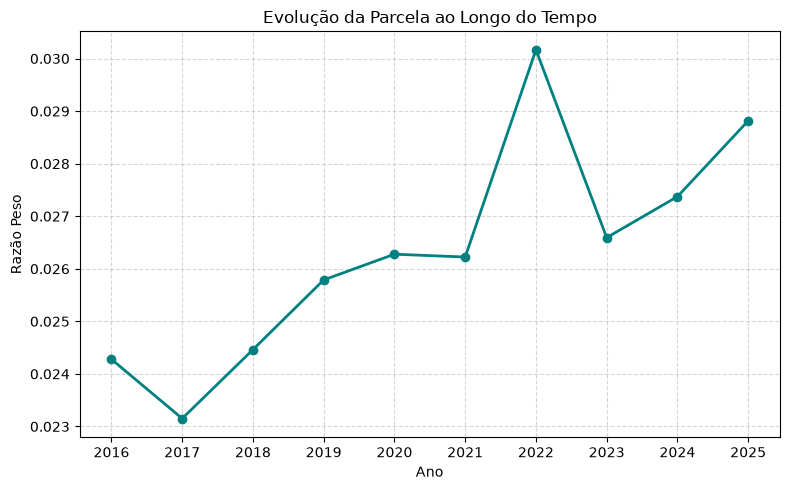

In [150]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Padronizar o nome da coluna de ano na tabela df_exp para combinar com df_1
df_exp_temp = df_exp.rename(columns={'CO_ANO': 'Year'})

# 2. Fundir (merge) as duas tabelas
# Usamos how='inner' para calcular a razão apenas nos anos que existem em ambas (2020 a 2024)
df_merged = pd.merge(df_exp_temp, df_1, on='Year', how='inner')

# 3. Calcular a parcela (razão)
# Aqui estou dividindo o KG_LIQUIDO pelo Value. 
# Se a sua lógica exigir o inverso (Value / KG_LIQUIDO), basta inverter a ordem aqui:
df_merged['Parcela'] = df_merged['Value'] / df_merged['KG_LIQUIDO']

# 4. Criar a figura e os eixos do gráfico
fig, ax = plt.subplots(figsize=(8, 5))

# Plotar a linha da parcela ao longo do tempo
ax.plot(df_merged['Year'], df_merged['Parcela'], marker='o', linewidth=2, color='teal')

# 5. Formatação do gráfico
ax.set_title("Evolução da Parcela ao Longo do Tempo")
ax.set_xlabel("Ano")
ax.set_ylabel("Razão Peso")

# Forçar o eixo X a mostrar apenas os anos exatos (evita números como 2020.5)
ax.set_xticks(df_merged['Year'].unique())

# Adicionar uma grade sutil para facilitar a leitura dos valores
ax.grid(True, linestyle='--', alpha=0.5)

# Ajustar margens e exibir
plt.tight_layout()
plt.show()

## Similaridade e complementaridade da pauta